In [3]:
!pip install google-genai

In [4]:
from google import genai
from google.colab import userdata
userdata.get('GEMINI_API_KEY')

import nltk #natural language toolkit
from nltk.corpus import stopwords, gutenberg
from wordcloud import WordCloud
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download("gutenberg") #collection of free books
nltk.download("vader_lexicon") #for sentiment analysis
nltk.download("stopwords") #additional: needed for wordclouds
nltk.download("punkt") #list of punctuation marks
nltk.download("punkt_tab") #newer version of punkt
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [5]:
text = "Data science is a multidisciplinary field combining statistics, mathematics, programming (Python, SQL), and domain expertise to extract actionable insights from structured and unstructured data. It uses machine learning to build predictive models, aiding in strategic decision-making and business growth, with high demand projected for professionals in this sector. "

In [6]:
words = word_tokenize(text)
words

['Data',
 'science',
 'is',
 'a',
 'multidisciplinary',
 'field',
 'combining',
 'statistics',
 ',',
 'mathematics',
 ',',
 'programming',
 '(',
 'Python',
 ',',
 'SQL',
 ')',
 ',',
 'and',
 'domain',
 'expertise',
 'to',
 'extract',
 'actionable',
 'insights',
 'from',
 'structured',
 'and',
 'unstructured',
 'data',
 '.',
 'It',
 'uses',
 'machine',
 'learning',
 'to',
 'build',
 'predictive',
 'models',
 ',',
 'aiding',
 'in',
 'strategic',
 'decision-making',
 'and',
 'business',
 'growth',
 ',',
 'with',
 'high',
 'demand',
 'projected',
 'for',
 'professionals',
 'in',
 'this',
 'sector',
 '.']

In [7]:
filtered_words = []

for i in words:
  if i.lower() not in stopwords.words("english") and i.isalpha():
    filtered_words.append(i.lower())

filtered_words

  #what we are doing: if the word is not in stopwords and is not a punctuation, we want it, so we add it to the list filtered_words

['data',
 'science',
 'multidisciplinary',
 'field',
 'combining',
 'statistics',
 'mathematics',
 'programming',
 'python',
 'sql',
 'domain',
 'expertise',
 'extract',
 'actionable',
 'insights',
 'structured',
 'unstructured',
 'data',
 'uses',
 'machine',
 'learning',
 'build',
 'predictive',
 'models',
 'aiding',
 'strategic',
 'business',
 'growth',
 'high',
 'demand',
 'projected',
 'professionals',
 'sector']

In [8]:
filtered_text = " ".join(filtered_words)
filtered_text

'data science multidisciplinary field combining statistics mathematics programming python sql domain expertise extract actionable insights structured unstructured data uses machine learning build predictive models aiding strategic business growth high demand projected professionals sector'

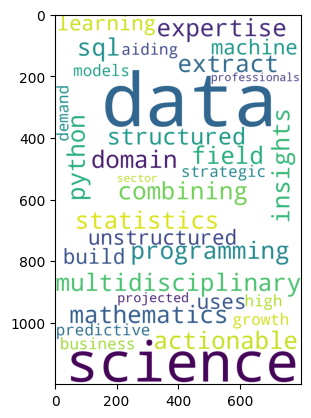

In [9]:
import matplotlib.pyplot as plt
fig = WordCloud(width=800, height=1200, background_color="white").generate(filtered_text)
plt.axis="off"
plt.imshow(fig)


<Axes: xlabel='Samples', ylabel='Counts'>

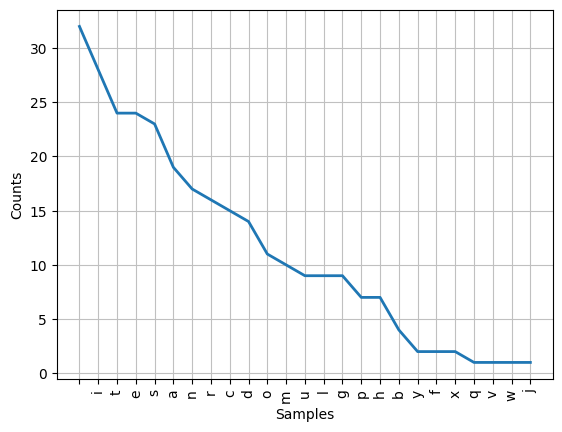

In [10]:
freq_dist = nltk.FreqDist(filtered_text)
freq_dist.plot()

In [11]:

import pandas as pd
df = pd.DataFrame(freq_dist.most_common(20), columns=["Words", "Counts"])

import plotly.express as px
fig2 = px.bar(df, x="Words", y="Counts")
fig2.show()

In [12]:
nltk.corpus.gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [13]:
ebook = gutenberg.raw('shakespeare-hamlet.txt')

#Activity: remove stopwords, punctuation marks, and plot the wordcloud!
words = word_tokenize(ebook)
filtered_words = []

In [14]:
sia = SentimentIntensityAnalyzer()
# sia.polarity_scores("I love FIU")
sia.polarity_scores("Love") #1.0 pos word 'Love'


{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.6369}

In [15]:
import os
# Assuming userdata is from a Google Colab environment
# from google.colab import userdata

client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))

system_prompt = "You are a friendly data science tutor. Explain things simply. Short answers only."
# system_prompt = "Short and rude. Don't be nice."

question = input("You: ")

# Correct way to pass system instructions using GenerateContentConfig
response = client.models.generate_content(
    model="gemini-2.5-flash",  # Note: Updated to a stable, current model version
    contents=question,
    config={'system_instruction': system_prompt}
)

if response.text:
    print("Bot:", response.text)

You: hi bobby
Bot: Hey there! How can I help you today?
